In [1]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt

In [2]:
import tensorflow as tf
from tensorflow import keras

2026-04-26 18:16:07.542138: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Database of fashion items
Link to the dataset: https://keras.io/datasets/#fashion-mnist-database-of-fashion-articles
Dataset of 60,000 28x28 grayscale images of 10 fashion categories, along with a test set of 10,000 images. The classes are:
The class labels are:

0. T-shirt/top
1. Trouser
2. Pullover
3. Dress
4. Coat
5. Sandal
6. Shirt
7. Sneaker
8. Bag
9. Ankle boot

### Usage
The Keras API makes it easy to load the Fashion MNIST dataset:

```python
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
```
This returns 2 tuples: the first is the training data and the second is the test data. Each tuple contains the images and their corresponding labels. The images are 28x28 NumPy arrays, and the labels are integers representing the class of each image.
The shape of the training data is (60000, 28, 28) and the shape of the test data is (10000, 28, 28). The labels are integers from 0 to 9, corresponding to the classes listed above.


In [3]:
fashion_mnist = keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

In [4]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

### Data Reshape

In [5]:
X_train_full = X_train_full.reshape((60000, 28, 28, 1)) # 60,000 images, 28x28 pixels, 1 color channel (grayscale)
X_test = X_test.reshape((10000, 28, 28, 1)) # 10,000 images, 28x28 pixels, 1 color channel (grayscale)

### Data normalization

In [6]:
X_train_n = X_train_full / 255.0
X_test_n = X_test / 255.0

#### Split the data into training and validation sets
- Training data - used to train the model
- Validation data - used to evaluate the model during training and tune hyperparameters
- Test data - used to evaluate the model after training is complete

In [7]:
X_valid, X_train = X_train_n[:5000], X_train_n[5000:]
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
X_test = X_test_n

### Createing the model architecture

In [8]:
np.random.seed(42)
tf.random.set_seed(42)

In [9]:
model = keras.models.Sequential()
model.add(keras.layers.Conv2D(filters=32, kernel_size=(3, 3), 
            strides=1, padding='valid', 
            activation='relu', input_shape=[28, 28, 1]))
model.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(300, activation='relu'))
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dense(10, activation='softmax'))

/opt/miniconda3/envs/tf_env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │     1,622,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,654,130 (6.31 MB)

 Trainable params: 1,654,130 (6.31 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(loss='sparse_categorical_crossentropy',
              optimizer='sgd',
              metrics=['accuracy'])

In [12]:
model_history = model.fit(X_train, y_train, epochs=10,
                          validation_data=(X_valid, y_valid),
                          batch_size=64)

Epoch 1/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 37s 42ms/step - accuracy: 0.6080 - loss: 1.2077 - val_accuracy: 0.7532 - val_loss: 0.6759
Epoch 2/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 34s 39ms/step - accuracy: 0.8012 - loss: 0.5522 - val_accuracy: 0.7998 - val_loss: 0.5542
Epoch 3/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 39s 45ms/step - accuracy: 0.8236 - loss: 0.4838 - val_accuracy: 0.8180 - val_loss: 0.5060
Epoch 4/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 37s 43ms/step - accuracy: 0.8373 - loss: 0.4462 - val_accuracy: 0.8302 - val_loss: 0.4662
Epoch 5/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 35s 41ms/step - accuracy: 0.8473 - loss: 0.4194 - val_accuracy: 0.8420 - val_loss: 0.4379
Epoch 6/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 28s 33ms/step - accuracy: 0.8557 - loss: 0.3984 - val_accuracy: 0.8484 - val_loss: 0.4173
Epoch 7/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 37s 43ms/step - accuracy: 0.8620 - loss: 0.3805 - val_accuracy: 0.8576 - val_loss: 0.3985
Epoch 8/10
860/860 ━━━━━━━━━━━━━━━━━━━━ 33s 38ms/step - accuracy: 0.8673 - loss: 0.3646 - 

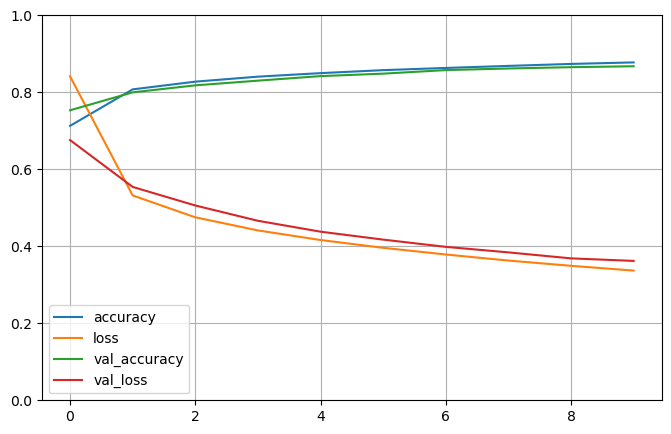

In [13]:
import pandas as pd

pd.DataFrame(model_history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

In [14]:
ev = model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8550 - loss: 0.3997


In [15]:
ev

[0.4042409360408783, 0.8500000238418579]

In [16]:
X_new = X_test[:3]

In [17]:
y_pred = model.predict(X_new)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


array([[1.3671316e-04, 2.9072486e-05, 3.5266588e-05, 8.1960767e-05,
        3.1292955e-05, 3.1991284e-02, 3.2957961e-04, 2.6752886e-01,
        8.4085930e-03, 6.9142735e-01],
       [3.3271430e-05, 5.5536236e-07, 9.7778338e-01, 3.9714400e-06,
        1.3057897e-02, 4.8512843e-09, 9.1181332e-03, 2.8117968e-09,
        2.7765605e-06, 2.1045092e-09],
       [2.2947615e-06, 9.9991298e-01, 1.2466531e-06, 1.1310110e-05,
        7.1316623e-05, 3.6577990e-09, 8.3833879e-07, 3.9712837e-09,
        4.9163390e-08, 9.4111723e-09]], dtype=float32)

In [18]:
y_test[:3]

array([9, 2, 1], dtype=uint8)

AxesImage(shape=(28, 28))


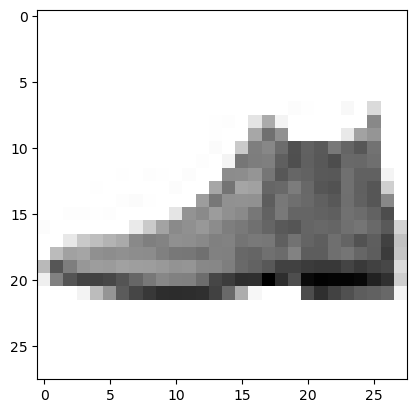

In [19]:
print(plt.imshow(X_test[0].reshape(28, 28), cmap="binary"))

In [20]:
del model
keras.backend.clear_session()

## Pooling vs No Pooling

In [21]:
model_a = keras.models.Sequential()
model_a.add(keras.layers.Conv2D(filters=32, kernel_size=(3, 3), 
            strides=1, padding='valid', 
            activation='relu', input_shape=[28, 28, 1]))
model_a.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))
model_a.add(keras.layers.Flatten())
model_a.add(keras.layers.Dense(300, activation='relu'))
model_a.add(keras.layers.Dense(100, activation='relu'))
model_a.add(keras.layers.Dense(10, activation='softmax'))

model_b = keras.models.Sequential()
model_b.add(keras.layers.Conv2D(filters=32, kernel_size=(3, 3), 
            strides=1, padding='valid', 
            activation='relu', input_shape=[28, 28, 1]))
model_b.add(keras.layers.Flatten())
model_b.add(keras.layers.Dense(300, activation='relu'))
model_b.add(keras.layers.Dense(100, activation='relu'))
model_b.add(keras.layers.Dense(10, activation='softmax'))

/opt/miniconda3/envs/tf_env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
model_a.summary()
model_b.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │     1,622,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,654,130 (6.31 MB)

 Trainable params: 1,654,130 (6.31 MB)

 Non-trainable params: 0 (0.00 B)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 21632)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 300)            │     6,489,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,521,330 (24.88 MB)

 Trainable params: 6,521,330 (24.88 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model_a.compile(loss='sparse_categorical_crossentropy',
              optimizer='sgd',
              metrics=['accuracy'])
model_b.compile(loss='sparse_categorical_crossentropy',
              optimizer='sgd',
              metrics=['accuracy'])

In [24]:
model_history_a = model_a.fit(X_train, y_train, epochs=3,
                          validation_data=(X_valid, y_valid),
                          batch_size=64)
model_history_b = model_b.fit(X_train, y_train, epochs=3,
                          validation_data=(X_valid, y_valid),
                          batch_size=64)

Epoch 1/3
860/860 ━━━━━━━━━━━━━━━━━━━━ 32s 37ms/step - accuracy: 0.6047 - loss: 1.2290 - val_accuracy: 0.7164 - val_loss: 0.7631
Epoch 2/3
860/860 ━━━━━━━━━━━━━━━━━━━━ 34s 39ms/step - accuracy: 0.7979 - loss: 0.5528 - val_accuracy: 0.7824 - val_loss: 0.6029
Epoch 3/3
860/860 ━━━━━━━━━━━━━━━━━━━━ 33s 38ms/step - accuracy: 0.8242 - loss: 0.4857 - val_accuracy: 0.8074 - val_loss: 0.5246
Epoch 1/3
860/860 ━━━━━━━━━━━━━━━━━━━━ 66s 76ms/step - accuracy: 0.6546 - loss: 1.0581 - val_accuracy: 0.7506 - val_loss: 0.6997
Epoch 2/3
860/860 ━━━━━━━━━━━━━━━━━━━━ 68s 79ms/step - accuracy: 0.8117 - loss: 0.5173 - val_accuracy: 0.7918 - val_loss: 0.5784
Epoch 3/3
860/860 ━━━━━━━━━━━━━━━━━━━━ 72s 84ms/step - accuracy: 0.8350 - loss: 0.4538 - val_accuracy: 0.8222 - val_loss: 0.4918


In [25]:
del model_a, model_b
keras.backend.clear_session()